In [85]:
import sys
import os 

import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 

sys.path.append(os.path.abspath(".."))

# 1. LOADING THE DATASET FOR ANALYSIS

In [2]:
from src.data.load_data import load_raw_data

df = load_raw_data("../data/raw/Online Retail.xlsx")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


* Each data point in the dataset represents a single product purchased by a customer as  
part of a specific transaction.  

* Multiple products may add up in a single transaction,  
  resulting in multiple data points for the same purchase. 

* The dataset is therefore at a transaction-line level.  

In [3]:
print("Initial data points present in the dataset: ",df.shape)

Initial data points present in the dataset:  (541909, 8)


## 1. DATA QUALITY ANALYSIS 

**1. MISSING VALUE ANALYSIS**

In [4]:
df.isnull().mean()

InvoiceNo      0.000000
StockCode      0.000000
Description    0.002683
Quantity       0.000000
InvoiceDate    0.000000
UnitPrice      0.000000
CustomerID     0.249267
Country        0.000000
dtype: float64

* CustomerID: ~25.0% missing  
* Description: ~0.26% missing  

In [5]:
df[df["CustomerID"].isnull()].head()

df[df["CustomerID"].isnull()].describe()

df[df["CustomerID"].isnull()]["Country"].value_counts()

Country
United Kingdom    133600
EIRE                 711
Hong Kong            288
Unspecified          202
Switzerland          125
France                66
Israel                47
Portugal              39
Bahrain                2
Name: count, dtype: int64

Rows with missing CustomerID appears to represent transactions without a  
unique customer identifier. These may corresponds to guest users or  
anonymous purchases. Hence, these rows are unsuitable for customer-level modeling.  

In [6]:
customerID_missing = df["CustomerID"].isnull().mean()*100
description_missing = df["Description"].isnull().mean()*100

print(f"Total Data points affected due to missing values of CustomerIDs: {customerID_missing}")
print(f"Total Data points affected due to missing Descriptions: {description_missing}")

Total Data points affected due to missing values of CustomerIDs: 24.926694334288598
Total Data points affected due to missing Descriptions: 0.2683107311375157


**COMBINED IMPACT :**  

In [7]:
affected_points = ((df["CustomerID"].isnull()) | (df["Description"].isnull())).mean()*100

print("Total number of data points having either missing Descriptions or customerID: ", affected_points)

Total number of data points having either missing Descriptions or customerID:  24.926694334288598


Approximately 24.93% of the dataset contains missing values in either  
CustomerID or Description, indicating that 24.93% of the data points from the datasets  
may not be usable for certian analysis.

**BAR PLOT**

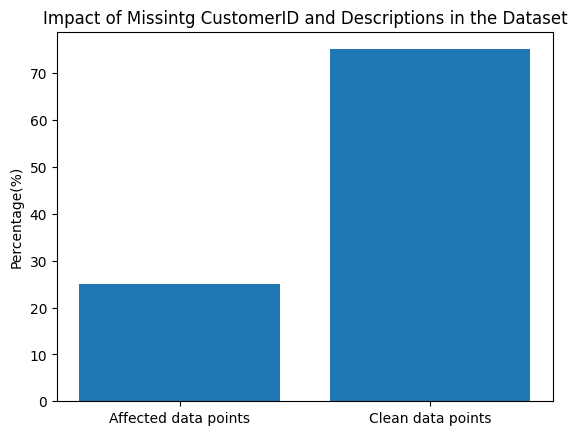

In [8]:
clean_points = 100 - affected_points

plt.bar(["Affected data points", "Clean data points"], [affected_points, clean_points])
plt.title("Impact of Missintg CustomerID and Descriptions in the Dataset")
plt.ylabel("Percentage(%)")

plt.show()

**Final Insight**
* The missing CustomerID values are not random but structurally missing,  
  indicating a specific class of transactions rather than data curruption.  
* CustomerID missing values represent transactions without identfiable customers.  
* These records cannot be used for customer-level feature engineering.  
* Description missing values are minimal.  
* A significant portion (~25%) of the dataset is affected by missing  
  CustomerID, which influence downstream modeling decisions. 

**Cleaning missing values from the dataset**  
df_rmr (DataFrame with removed missing values)

In [9]:
df_rmr = df.dropna(subset=["CustomerID", "Description"])

In [10]:
print("Total data points after dropping points containing missing CustomerID and Descriptions: ", df_rmr.shape)

Total data points after dropping points containing missing CustomerID and Descriptions:  (406829, 8)


**2. DATA TYPE CONSISTENCY**

In [11]:
df_rmr.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

In [12]:
df_rmr["CustomerID"].apply(type).value_counts()

CustomerID
<class 'float'>    406829
Name: count, dtype: int64

Converting CustomerID feature into an int type to avoid future failures 

In [13]:
df_rmr["CustomerID"] = df_rmr["CustomerID"].astype(int)

C:\Users\rachit\AppData\Local\Temp\ipykernel_16188\3262758149.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_rmr["CustomerID"] = df_rmr["CustomerID"].astype(int)


In [14]:
df_rmr["CustomerID"].apply(type).value_counts()

CustomerID
<class 'int'>    406829
Name: count, dtype: int64

In [15]:
df_rmr.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID              int64
Country                object
dtype: object

Data types were verified for consistency across all columns.  
InvoiceDate is correctly stored as datetime for time-based analysis.  
Numerical features such as Quantity and UnitPrice for aggregation.  
CustomerID converted to string to represent it as a categorical identifier.  
All columns are now consistent and ready for further analysis. 

**3. INVALID & CORRUPTED DATA**

In [16]:
df_rmr.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,406829.000000,406829,406829.000000,406829.000000
mean,12.061303,2011-07-10 16:30:57.879207424,3.460471,15287.690570
min,-80995.000000,2010-12-01 08:26:00,0.000000,12346.000000
25%,2.000000,2011-04-06 15:02:00,1.250000,13953.000000
50%,5.000000,2011-07-31 11:48:00,1.950000,15152.000000
75%,12.000000,2011-10-20 13:06:00,3.750000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,248.693370,NaN,69.315162,1713.600303


In [17]:
df_rmr["InvoiceNo"].astype(str).str.startswith("C").mean()*100

np.float64(2.188880340388714)

Approximately 1.7% of transactions corresponds to the cancelled invoices.  
Cancelled invoices are removed to ensure that only valid purchase transactions  
are retained.  

Removing the points with cancelled invoices. 

In [18]:
cancelled_mask = df_rmr["InvoiceNo"].astype(str).str.startswith("C")
df_canc_inv= df_rmr[~cancelled_mask]

In [19]:
print("Total data points after dropping points with cancelled invoices: ", df_canc_inv.shape)

Total data points after dropping points with cancelled invoices:  (397924, 8)


Resetting the indices

In [20]:
df_canc_inv = df_canc_inv.reset_index(drop = True)

In [21]:
print("Data points with respect to the cancelled invoices: \n")
print("Before: ", len(df_rmr))
print("After: ", len(df_canc_inv))


Data points with respect to the cancelled invoices: 

Before:  406829
After:  397924


In [22]:
df_canc_inv["StockCode"].value_counts()

StockCode
85123A    2035
22423     1724
85099B    1618
84879     1408
47566     1397
          ... 
90214Z       1
90214U       1
23449        1
90214W       1
23843        1
Name: count, Length: 3665, dtype: int64

In [23]:
df_canc_inv["StockCode"].unique()[30:50]

array([21883, 10002, 21791, 21035, 22326, 22629, 22659, 22631, 22661,
       21731, 22900, 21913, 22540, 22544, 22492, 'POST', 22086, 20679,
       37370, 21871], dtype=object)

Certain StockCode values such as "POST" represents no-product entries  
like shipping charges. These are retained at this stage as they contribute  
to total transaction value but may be excluded in product-specific analyses later. 

In [24]:
print("Total number of data points with -ve quantities: ", (df_canc_inv["Quantity"] < 0 ).sum())
print("Minimum quantitiy of a product in a transaction: ", (df_canc_inv["Quantity"]).min())

Total number of data points with -ve quantities:  0
Minimum quantitiy of a product in a transaction:  1


In [25]:
(df["Quantity"] <= 0 ).sum()

np.int64(10624)

In [26]:
(df_canc_inv["Quantity"] <= 0 ).sum()

np.int64(0)

This represents that Negative quantity values were not observed after  
removing cancelled invoices and missing values, indicating that return transactions  
were already excluded during earlier cleaning steps. 

In [27]:
df_canc_inv["InvoiceDate"].dtype

dtype('<M8[ns]')

InvoiceDate represents the timestamp of transactions and is correctly   
formatted as datetime. No inconsistencies observed.  

In [28]:
df_canc_inv["UnitPrice"].min()

np.float64(0.0)

In [29]:
(df_canc_inv["UnitPrice"] == 0).sum()

np.int64(40)

There exists data points where UnitPrice of products is given 0.  
These data points possess no quality to be trained with,  
so removing them is the viable option.  

Removing the data points containing product UnitPrice = 0.

In [30]:
df_inv_price = df_canc_inv[df_canc_inv["UnitPrice"]  > 0]

In [31]:
df_inv_price = df_inv_price.reset_index(drop = True)

In [32]:
print("Total data points after dropping points containing products of UnitPrice = 0: ", df_inv_price.shape)

Total data points after dropping points containing products of UnitPrice = 0:  (397884, 8)


In [33]:
df_inv_price["Country"].unique()

array(['United Kingdom', 'France', 'Australia', 'Netherlands', 'Germany',
       'Norway', 'EIRE', 'Switzerland', 'Spain', 'Poland', 'Portugal',
       'Italy', 'Belgium', 'Lithuania', 'Japan', 'Iceland',
       'Channel Islands', 'Denmark', 'Cyprus', 'Sweden', 'Finland',
       'Austria', 'Greece', 'Singapore', 'Lebanon',
       'United Arab Emirates', 'Israel', 'Saudi Arabia', 'Czech Republic',
       'Canada', 'Unspecified', 'Brazil', 'USA', 'European Community',
       'Bahrain', 'Malta', 'RSA'], dtype=object)

In [34]:
(df_inv_price["Country"] == "Unspecified").sum()

np.int64(244)

Data points having transaction of products from "Unspecified" country  
are no use in any means to the system . 

Removing the data points containing Unspecified country

In [35]:
df_clean = df_inv_price[df_inv_price["Country"] != "Unspecified"]

In [36]:
df_clean = df_clean.reset_index(drop = True)

In [37]:
print("Total data points after dropping points containing country = 'Unspecified': ", df_clean.shape)

Total data points after dropping points containing country = 'Unspecified':  (397640, 8)


**4. DUPLICATES**

In [38]:
# Check duplicates
print("Duplicate rows:", df_clean.duplicated().sum()) 

Duplicate rows: 5189


In [39]:
# Remove duplicates
df_clean = df_clean.drop_duplicates()

print("After removing duplicates:", df_clean.shape)

After removing duplicates: (392451, 8)


# 3. TRANSACTION ANALYSIS 

In [40]:
df_clean["Quantity"].describe()

count    392451.000000
mean         13.123210
std         180.548053
min           1.000000
25%           2.000000
50%           6.000000
75%          12.000000
max       80995.000000
Name: Quantity, dtype: float64

In [41]:
df_clean["UnitPrice"].describe()

count    392451.000000
mean          3.125856
std          22.248508
min           0.001000
25%           1.250000
50%           1.950000
75%           3.750000
max        8142.750000
Name: UnitPrice, dtype: float64

In [42]:
df_clean["Quantity"].quantile([0.01, 0.05, 0.95, 0.99])

0.01      1.0
0.05      1.0
0.95     36.0
0.99    120.0
Name: Quantity, dtype: float64

In [43]:
df_clean["UnitPrice"].quantile([0.01, 0.05, 0.95, 0.99])

0.01     0.21
0.05     0.42
0.95     8.50
0.99    14.95
Name: UnitPrice, dtype: float64

**Quantiles** analysis helps identify the concentration of most transactions  
and the presence of extreme values. For Quantity, 95% of transactions involve  
fewer than 36 items, and 99% are below 120, indicating that purchases in bulk are  
rare but significant. For UnitPrice, 95% of values lie below approximately 8.5  
and 99% below 15, confirming that most transactions involve low-cost items with  
a small number of outliers with high-price.

**HISTOGRAMS**

* QUANTITY

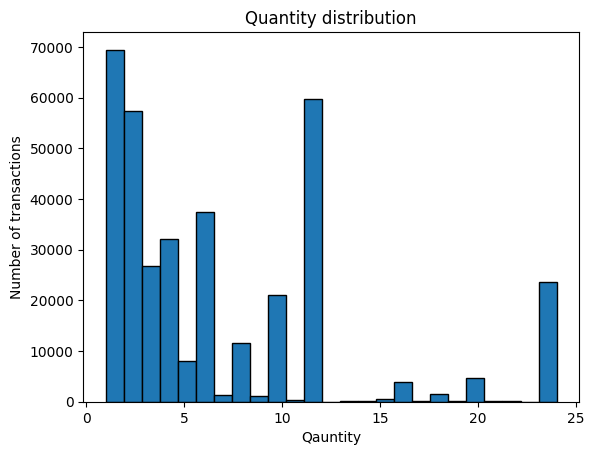

In [44]:
subset = df_clean[df_clean["Quantity"] <= df["Quantity"].quantile(0.9)]
plt.hist(subset["Quantity"], bins = 25, edgecolor = "black")

plt.xlabel("Qauntity")
plt.ylabel("Number of transactions")
plt.title("Quantity distribution")

plt.show()

* Unit Price

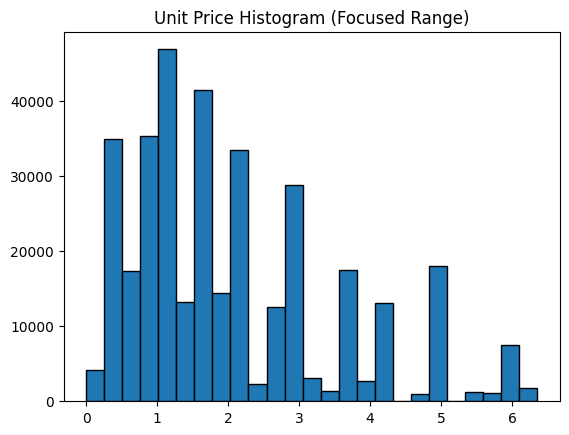

In [45]:
subset = df_clean[df_clean['UnitPrice'] <= df_clean["UnitPrice"].quantile(0.9)]

plt.hist(subset['UnitPrice'], bins=25, edgecolor='black')
plt.title("Unit Price Histogram (Focused Range)")
plt.show()

**BAR PLOTS**

* Quantity

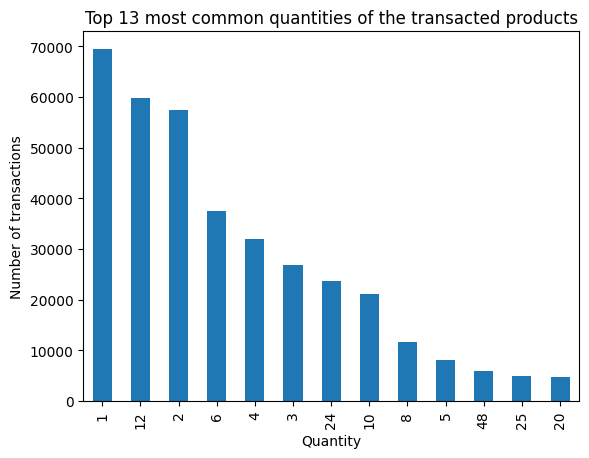

In [46]:
df_clean["Quantity"].value_counts().head(13).plot(kind = "bar")

plt.xlabel("Quantity")
plt.ylabel("Number of transactions")
plt.title("Top 13 most common quantities of the transacted products")
plt.show()

* Unit Price

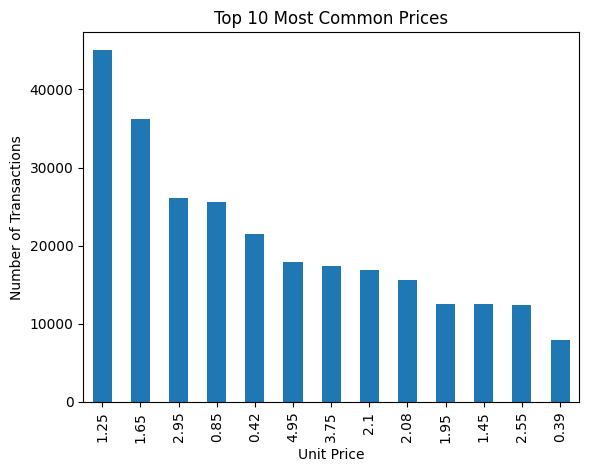

In [47]:
df_clean['UnitPrice'].value_counts().head(13).plot(kind='bar')

plt.xlabel("Unit Price")
plt.ylabel("Number of Transactions")
plt.title("Top 10 Most Common Prices")

plt.show()

### Distribution and Frequency Analysis of Quantity and UnitPrice

The Quantity and UnitPrice features were analyzed using both histogram and frequency-based (bar plot)  
visualizations to understand their distribution and behavior.

Both features exhibit strong right-skewness, with the majority of transactions concentrated at lower  
values and a long tail extending toward higher values. For Quantity, most transactions involve small  
values (primarily 1–4 items), while occasional large values indicate bulk purchasing behavior.  
For UnitPrice, most values lie in the lower price range (typically below 3), suggesting that the  
dataset is dominated by low-cost items.

However, both Quantity and UnitPrice are discrete in nature, with many values repeating frequently.   
 This is especially evident in UnitPrice, where specific price points such as 1.25 and 1.65 occur  
 very frequently, indicating a fixed, catalog-based pricing strategy rather than continuous variation.

Due to this discrete structure, histograms alone are insufficient for capturing the true distribution  
of values, as binning merges distinct values and obscures important patterns. While histograms were useful  
for identifying overall shape and skewness, bar plots of value frequencies provided a clearer and more  
accurate representation of the data by preserving exact value counts.

Therefore, bar plots were used as the primary tool for extracting insights, while histograms were used as  
supporting visualizations to understand overall distribution characteristics.


**BOXPLOT**

* Quantity

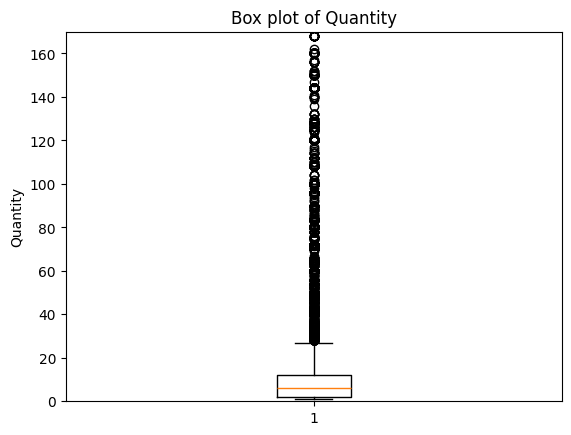

In [48]:
plt.boxplot(df_clean["Quantity"])

plt.title("Box plot of Quantity")
plt.ylim(0, 170)
plt.ylabel("Quantity")

plt.show()

* Unit Price 

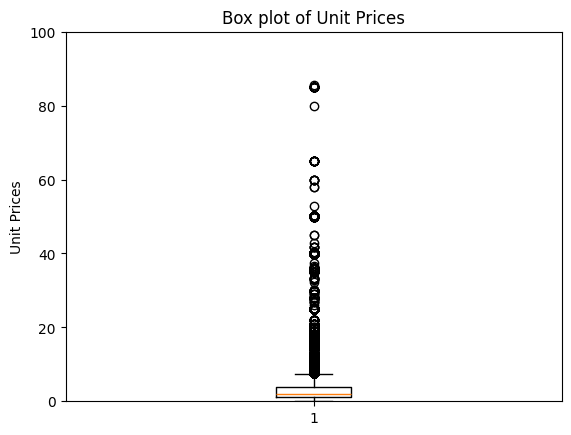

In [49]:
plt.boxplot(df_clean["UnitPrice"])

plt.title("Box plot of Unit Prices")
plt.ylim(0, 100)
plt.ylabel("Unit Prices")

plt.show()

**Outlier and Spread Analysis**

Box plots were used to examine the spread and presence of outliers in both Quantity and UnitPrice.  
The majority of values for both features are concentrated in lower ranges, while a large number of  
higher values extend beyond the typical range.

For Quantity, most transactions fall between approximately 2 and 12 items, with numerous higher  
values indicating bulk purchasing behavior. For UnitPrice, most values are clustered at lower  
price levels, while a smaller number of higher-priced items appear as outliers.

The presence of many outliers reflects a long-tailed distribution rather than data errors,  
indicating diverse purchasing patterns within the dataset. These characteristics are typical  
of real-world transactional data and provide valuable signals for downstream modeling.


**REVENUE PLOT**

In [50]:
df_clean["Revenue"] = df_clean["Quantity"] * df_clean["UnitPrice"]

<function matplotlib.pyplot.show(close=None, block=None)>

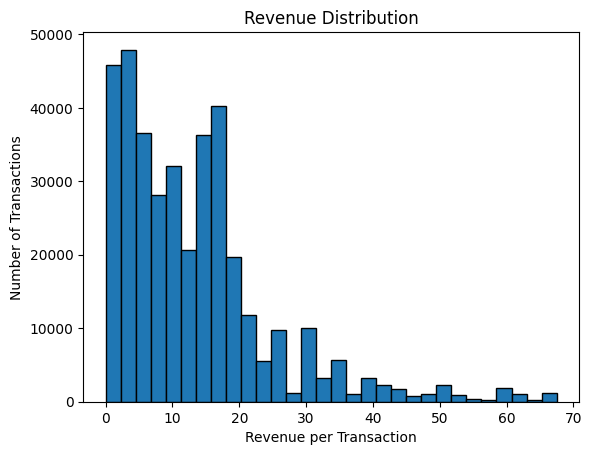

In [51]:
subset = df_clean[df_clean["Revenue"] <= df_clean["Revenue"].quantile(0.95)]

plt.hist(subset["Revenue"], bins = 30, edgecolor = "black")

plt.xlabel("Revenue per Transaction")
plt.ylabel("Number of Transactions")
plt.title("Revenue Distribution")

plt.show

**Revenue per Transaction Analysis**

Revenue per transaction was calculated as the product of Quantity and UnitPrice.  
The histogram (focused on the 95th percentile) shows a strongly right-skewed distribution,  
where the majority of transactions generate low revenue, primarily concentrated in the lower range.  

Most transactions fall within a relatively small revenue band, indicating that typical purchases  
involve low-cost items and small quantities. However, a long tail is observed toward higher revenue values,  
representing fewer but significantly larger transactions.  

This suggests that while most customers contribute small amounts to total revenue, a smaller number of  
transactions—likely bulk purchases or higher-priced items—play a disproportionately important role in  
overall revenue generation. Such a distribution is characteristic of real-world retail data,   
where high-value transactions drive a significant portion of business impact.  


**BASKET SIZE**

In [52]:
basket_size = df_clean.groupby("InvoiceNo")["Quantity"].sum()

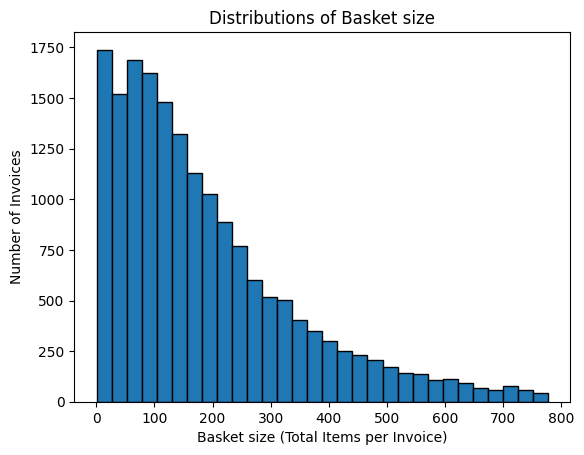

In [53]:
subset = basket_size[basket_size <= basket_size.quantile(0.95)]

plt.hist(subset, bins = 30, edgecolor = "black")

plt.xlabel("Basket size (Total Items per Invoice)")
plt.ylabel("Number of Invoices")
plt.title("Distributions of Basket size")

plt.show()

**Basket Size Analysis**

Basket size was computed as the total quantity of items per invoice.  
The distribution shows a strong right-skew, with most invoices containing a small number of items,  
 while a smaller number of invoices include significantly larger quantities.  

This indicates that typical customer purchases involve a limited number of products,   
whereas occasional bulk purchases contribute to larger basket sizes. The presence of a long tail   
suggests variability in purchasing behavior, with both individual and bulk buying patterns observed in the dataset.


## 4. CUSTOMER ANALYSIS 

**1. Customer-Level data**

In [68]:
# Creating a DataFrame for customer analysis 
customer_df = df_clean.groupby("CustomerID").agg({
    "InvoiceNo": "nunique",      
    "Revenue": "sum",
    "Quantity" : "sum",
    "InvoiceDate" : {"max", "min"}
})

# Renaming the columns
customer_df.columns = ["frequency", "monetary", "total_quantity", "last_purchase", "first_purchase"]

customer_df.reset_index(drop = True)

,frequency,monetary,total_quantity,last_purchase,first_purchase
0,1,77183.60,74215,2011-01-18 10:01:00,2011-01-18 10:01:00
1,7,4310.00,2458,2010-12-07 14:57:00,2011-12-07 15:52:00
2,4,1797.24,2341,2010-12-16 19:09:00,2011-09-25 13:13:00
3,1,1757.55,631,2011-11-21 09:51:00,2011-11-21 09:51:00
4,1,334.40,197,2011-02-02 16:01:00,2011-02-02 16:01:00
...,...,...,...,...,...
4329,1,180.60,45,2011-03-07 09:52:00,2011-03-07 09:52:00
4330,1,80.82,54,2011-06-12 10:53:00,2011-06-12 10:53:00
4331,2,178.05,103,2011-08-05 13:35:00,2011-12-02 11:43:00
4332,16,2045.53,1357,2011-01-06 14:14:00,2011-12-06 12:02:00


Adding Recency and AOV

In [ ]:
max_date = df_clean["InvoiceDate"].max()

customer_df["Recency"] = (max_date - customer_df["last_purchase"]).dt.days
customer_df["AOV"] = (customer_df["monetary"]/customer_df["frequency"])

* Converted transaction-level data into customer-level dataset   

* Created behavioral metrics: frequency, monetary, recency, AOV  

* This dataset will be used for deeper customer behavior analysis   

**2. Total spend per Customer**

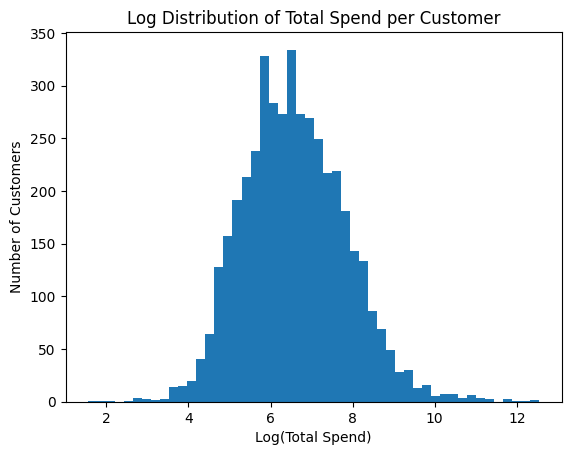

In [95]:
plt.figure()
subset = customer_df["monetary"]
log_monetary = np.log1p(subset)
plt.hist(log_monetary, bins = 50)
plt.title("Log Distribution of Total Spend per Customer")
plt.xlabel("Log(Total Spend)")
plt.ylabel("Number of Customers")
plt.show()

**MONETARY ANALYSIS**
* Distribution is heavily right -skewed therefore, monetary is approximately   
  following a Log-Normal Distribution as log(monetary) is clearly following a Gaussian Distribution.     
  
* Majority of the customers have spends around 5 - 8.  

**3. Transactions per Customer**

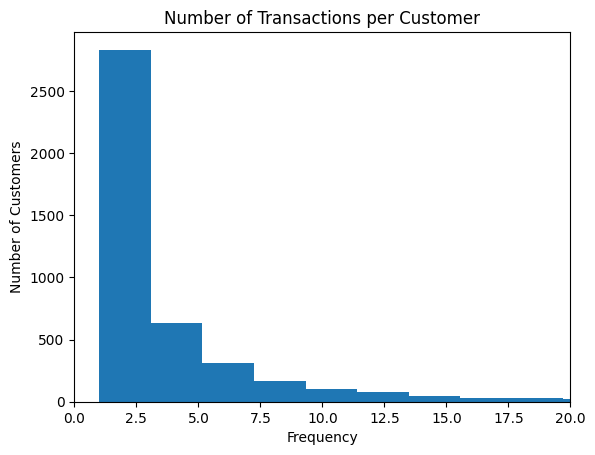

In [117]:
plt.figure()
subset = customer_df["frequency"]
plt.hist(subset, bins = 100)
plt.title("Number of Transactions per Customer")
plt.xlim(0, 20)
plt.xlabel("Frequency")
plt.ylabel("Number of Customers")

plt.show()

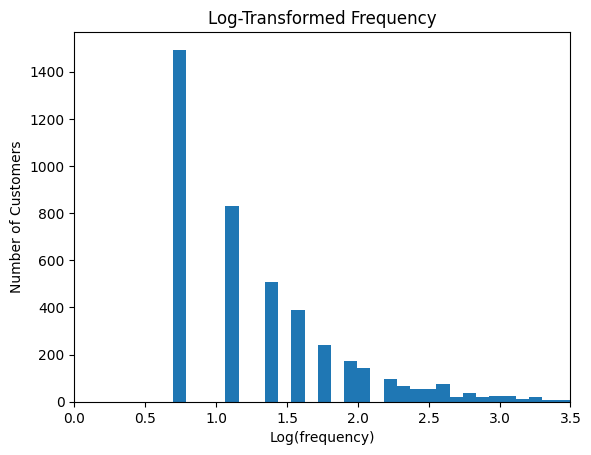

In [114]:
log_frequency = np.log1p(customer_df["frequency"])

plt.figure()
plt.hist(log_frequency, bins = 50)
plt.title("Log-Transformed Frequency")
plt.xlim(0, 3.5)
plt.xlabel("Log(frequency)")
plt.ylabel("Number of Customers")

plt.show()

**Frequency Analysis**
* Frequency distribution is highly right-skewed, with the majority  
  of customers making very few transactions, typically b/w 1 & 3.  
* A log transformation was applied to better understand the spread of  
  frequency of customers. While the transformation reduces skewness, the  
  distribution remains asymmetric, suggesting that transaction frequency  
  does not follow a Log-Normal Distribution.  

**4. ACTIVITY PER CUSTOMER**


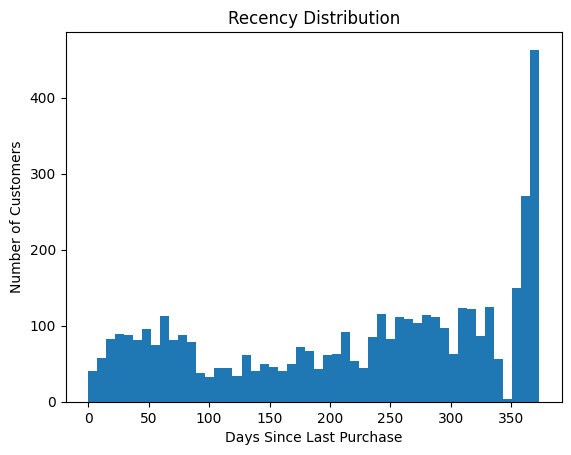

In [115]:
plt.figure() 
plt.hist(customer_df["Recency"], bins= 50)
plt.title("Recency Distribution")
plt.xlabel("Days Since Last Purchase")
plt.ylabel("Number of Customers")

plt.show()

**RECENCY ANALYSIS**
* The recency distribution spans from very recent activity to long preiods of  
  inactivity.  

* A noticeable concentration of customers at high recency values suggests a large   
  inactive or ptoentially churned segment, while low recency value represent  
  recently active users.  
  
* Recency is therefore a strong indicator of engagement and will be crtiical  
  for churn prediction and customer segmentation.  

# TIME-BASED ANALYSIS 

In [ ]:
# Ensuring datatime 
df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])

# Time Features 
df_clean["year"] = df_clean["InvoiceDate"].dt.year
df_clean["month"] = df.clean["InvoiceDate"].dt.month
df_clean["day"] = df_clean["InvoiceDate"].dt.day 
df_clean["day_of_week"] = df_clean["InvoiceDate"].dt.dayofweek
df_clean["hour"] = df_clean["InvoiceDate"].dt.hour
df_clean["year_month"] = df_clean["InvoiceDate"].dt.to_period("M")

**1. Monthly Orders Trend**

In [ ]:
monthly_orders = df_clean.groupby("year_month")["InvoiceNo"].nunique()

plt.figure()
monthly_orders.plot()
plt.title("Monthtly Orders Trend")
plt.xlabel("Month")
plt.ylabel("Number of orders")
plt.xticks(rotation = 45)
plt.show()

**2. Monthly Revenue Trend**

In [ ]:
monthly_revenue = df_clean.groupby("year_month")["Revenue"].sum()

plt.figure()
monthly_revenue.plot()
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotations = 45)
plt.show() 